## Problem 2

In [1]:
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data/nhl_players.csv')

a) Predictions based on intuition\
timeOnIce: positive relationship. Players with more minutes get more shot attempt opportunities which would lead to more goals.\
assists: positive relationship. A player with more assists is likely to be a better offensive player who will also score more\
shots: strong positive relationship. Taking more shots directly lead to a higher chance of scoring and should be the strongest predictor of number of goals.\
penalty_minutes: unclear. A player with more penalty minutes may have a more physical play style that doesn't necessarily lead to scoring.


b) Scatter matrix of features

In [2]:
# scatter matrix
features = ['timeOnIce', 'assists', 'shots', 'penaltyMinutes', 'goals']

fig = px.scatter_matrix(
    df[features],
    dimensions=['timeOnIce', 'assists', 'shots', 'penaltyMinutes'],
    color='goals',           # color points by the target variable
    title='Scatter Matrix of NHL Player Features',
    labels={col: col for col in features}
)

fig.update_traces(marker=dict(size=2, opacity=0.5))
fig.show()


observations:
- each feature is perfectly correlated with itself
- timeOnIce, shots, and assists show strong to moderate positive relation with each other
- penaltyMinutes show weak correlation with the other features
- goals appear to be positively correlated with all 4 features

c) scatter plot of timeOnIce vs goals, coloured by shots

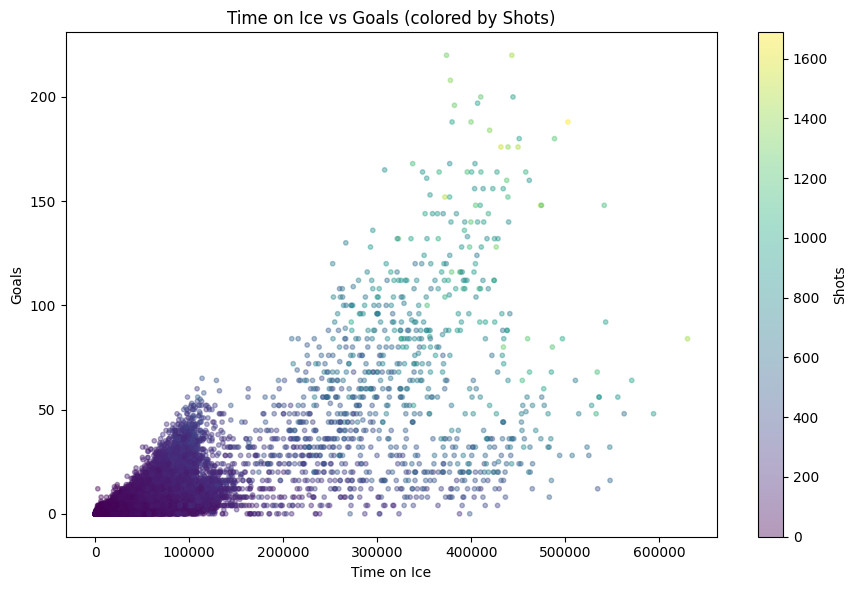

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df['timeOnIce'],
    df['goals'],
    c=df['shots'],          # color by shots (continuous)
    cmap='viridis',
    alpha=0.4,
    s=10
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Shots')

ax.set_xlabel('Time on Ice')
ax.set_ylabel('Goals')
ax.set_title('Time on Ice vs Goals (colored by Shots)')
plt.tight_layout()
plt.show()

d) scatter plot of timeOnIce vs goals, coloured by shots (categorized to low, medium, high)

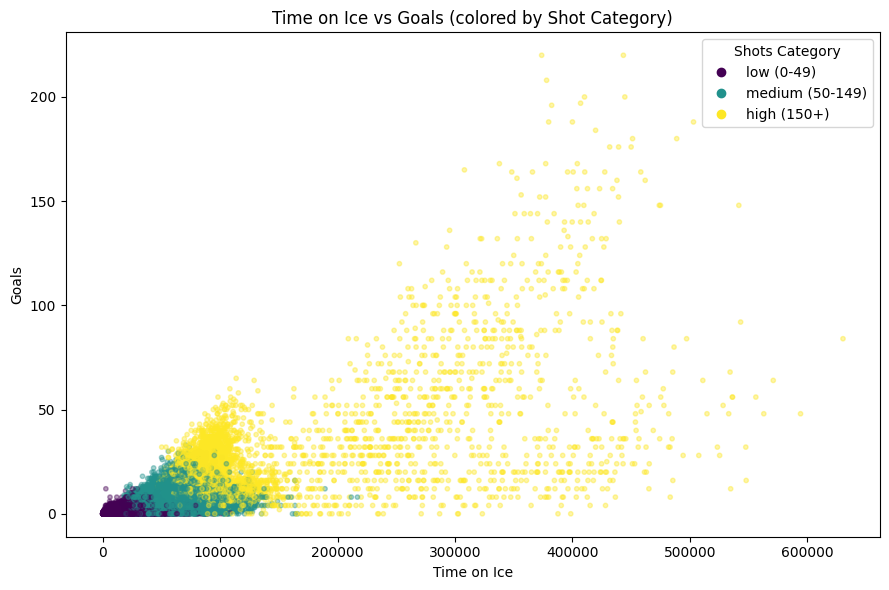

In [4]:
# change shots to a categorical variable (low, medium, high)
shots_category = pd.cut(
    df['shots'],
    bins=[-1, 49, 149, float('inf')],
    labels=['low (0-49)', 'medium (50-149)', 'high (150+)']
)

category_codes = shots_category.cat.codes

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df['timeOnIce'],
    df['goals'],
    c=category_codes,
    cmap='viridis',
    alpha=0.4,
    s=10
)

cmap = plt.get_cmap('viridis')
legend_labels = ['low (0-49)', 'medium (50-149)', 'high (150+)']
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=cmap(i / 2), label=label, markersize=6)
    for i, label in enumerate(legend_labels)
]
ax.legend(handles=legend_handles, title='Shots Category')

ax.set_xlabel('Time on Ice')
ax.set_ylabel('Goals')
ax.set_title('Time on Ice vs Goals (colored by Shot Category)')
plt.tight_layout()
plt.show()

observations from (c) and (d):
- the plots show a positive relationship between timeOnIce and goals
- The variance in goals increases as timeOnIce increases
- shots has a strong positive relationship with goals and timeOnIce. 

e) linear regression\
For the linear regression model y=Xθ
where $y \in \mathbb{R}^{n \times 1}$ and $X \in \mathbb{R}^{n \times p}$  
n = 16787, p = 5  
n is the size of the dataset
p the number of features + 1 for the bias term

f) 
Based on the visualizations and correlation analysis, we expect the following for the signs of the coefficients θ:
- θ_timeOnIce > 0: there is a positive relationship between timeOnIce and goals
- θ_assits > 0: there is a positive relationship between assists and goals
- θ_shots > 0: there is a positive relationship between shots and goals
- θ_penaltyMinutes: either, the value is expected to be near 0
- θ_bias: expected to be near zero. When all features = 0 the goals should be 0

g) target y and matrix X, split data

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

# construct X and y
X = df[['timeOnIce', 'assists', 'shots', 'penaltyMinutes']].values
X = np.column_stack([np.ones(len(X)), X])  # add bias column
y = df['goals'].values

print('X shape:', X.shape)
print('y shape:', y.shape)

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X shape: (16787, 5)
y shape: (16787,)


h) rank of X

In [6]:
rank = np.linalg.matrix_rank(X)
print('Rank of X:', rank)

Rank of X: 5


rank(X) = 5 = min(n,p), $X \in \mathbb{R}^{n \times p}$, so X is full rank.\
This means $X^TX$ is invertible, and there is a unique least-squares solution to $y=Xθ$

i) \
Equation for least-squares solution:
$$\hat{\theta} = (X^TX)^{-1}X^Ty$$

In [7]:
theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print('Estimated coefficients θ:', theta)

Estimated coefficients θ: [ 2.96389917e-01 -1.23380492e-04  1.90316770e-01  1.30929143e-01
  6.21488882e-03]


j) estimated coefficients:
- bias (θ_0=2.96E-1): expected number of goals when all features are zero
- timeOnIce (θ_1=-1.23E-4): near zero and slightly negative, showing that time on ice does not directly lead to more goals
- assists (θ_2=1.90E-1): a player is expected to score 0.19 more goals for each additional assist
- shots (θ_3=1.31E-1): a player is expected to score 0.13 more goals for each additional shot attempt
- penaltyMinutes (θ_4=6.214E-3): near zero, showing the effect of penalty minutes on goals is minimal

k) RMSE, R^2

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

y_train_pred = X_train @ theta
y_test_pred = X_test @ theta

print('Train RMSE:', rmse(y_train, y_train_pred))
print('Test RMSE:', rmse(y_test, y_test_pred))
print('Train R2:', r2(y_train, y_train_pred))
print('Test R2:', r2(y_test, y_test_pred))

Train RMSE: 6.625123935050331
Test RMSE: 6.597229126336596
Train R2: 0.8590315924083437
Test R2: 0.8566921896431091


The RMSE value of 6.6 means on average the model's predictions have an error of 6.6 goals. This is moderate error since the majority of players score less than 50 goals per season.

R^2 = 0.86 is the proportion of variance of goals explained by regression on X. This is strong since it is close to 1.

The training and testing sets produced nearly identical RMSE and R^2 values, showing that the model is not overfitted.

Overall the model provides a reasonably good estimate of goals. R^2 being close to 1 means most of the variance in goals can be explained by the four features, but an RMSE of 6.6 goals is relatively large for low scoring players.

l) Scatter plot of true y vs predicted y (test set)

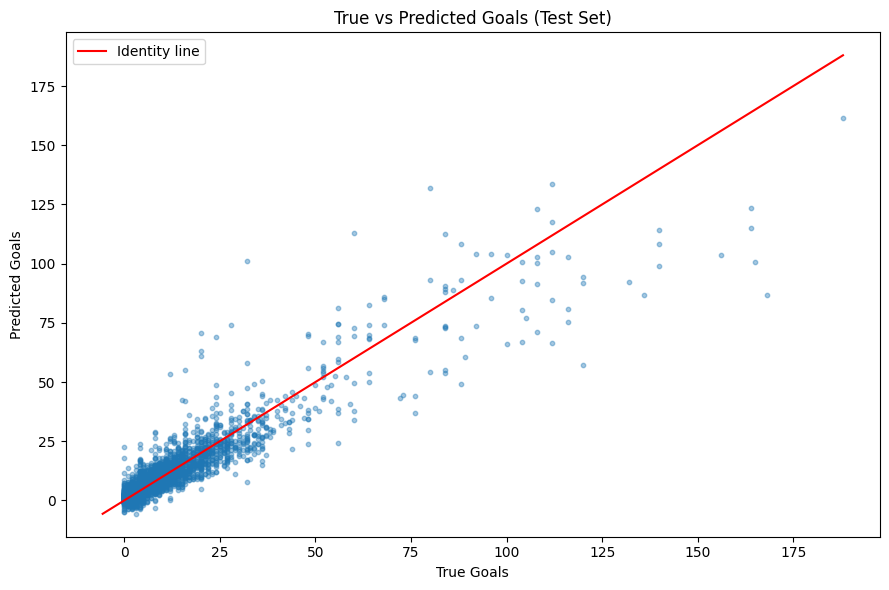

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(y_test, y_test_pred, alpha=0.4, s=10)

# identity line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r-', label='Identity line')

ax.set_xlabel('True Goals')
ax.set_ylabel('Predicted Goals')
ax.set_title('True vs Predicted Goals (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

m) linear regression with sklearn